<a href="https://colab.research.google.com/github/Aymanyah/Stat_app/blob/main/notebook/scouting_statapp_Raph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
import re
import unicodedata

In [15]:
import sys
import pandas as pd
import numpy as np
from pathlib import Path

# =====================================================================
# 1. GESTION DES CHEMINS (COLAB / LOCAL)
# =====================================================================
if 'google.colab' in sys.modules:
    if not Path('/content/Stat_app').exists():
        !git clone https://github.com/Aymanyah/Stat_app.git
    PROJECT_DIR = Path('/content/Stat_app')
else:
    PROJECT_DIR = Path.cwd().parent

DATA_RAW = PROJECT_DIR / "data" / "raw" / "all_leagues_merged_transformed.csv"
DATA_CLEAN_DIR = PROJECT_DIR / "data" / "clean"
DATA_CLEAN_DIR.mkdir(parents=True, exist_ok=True)

# =====================================================================
# 2. CHARGEMENT ET CORRECTION DES ENCODAGES
# =====================================================================
df = pd.read_csv(DATA_RAW, encoding="utf8")

def fix_text(s):
    if isinstance(s, str):
        try:
            return s.encode('latin1').decode('utf-8')
        except:
            return s
    return s

# Appliquer aux colonnes texte
text_cols = ["player", "team", "league", "nation", "pos"]
for col in text_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).apply(fix_text).str.strip()

# Nettoyage des noms de colonnes
df.columns = [fix_text(col).strip() for col in df.columns]

# Supprimer les doublons exacts
df_clean = df.drop_duplicates()

# =====================================================================
# 3. AGRÉGATION PAR SAISON
# =====================================================================
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != "season"]

def smart_agg(col):
    if "percent" in col.lower() or "%" in col or "ratio" in col.lower():
        return "mean"
    if col in ["Minutes de jeu", "G", "G-PK", "A", "Tirs", "Tirs cadrés", "Assists"]:
        return "sum"
    return "mean"

agg_dict = {col: smart_agg(col) for col in numeric_cols}

categorical_cols = [c for c in ["team", "league", "nation", "pos"] if c in df_clean.columns]
for col in categorical_cols:
    agg_dict[col] = "last"

df_grouped = df_clean.groupby(["player", "season"]).agg(agg_dict).reset_index()

# =====================================================================
# 4. SUPPRIMER LES STATS DE LA SAISON 2021 (identique à 2020)
# =====================================================================
df_grouped = df_grouped[df_grouped["season"] != 2021]

# =====================================================================
# 5. PIVOT LARGE : stats par saison
# =====================================================================
# Pivot colonnes numériques
df_stats = df_grouped.pivot(index="player", columns="season", values=numeric_cols)
df_stats.columns = [f"{stat}_{int(season)}" for stat, season in df_stats.columns]
df_stats = df_stats.reset_index()

# Pivot colonnes catégorielles
df_cats = {}
for col in categorical_cols:
    df_cat = df_grouped.pivot(index="player", columns="season", values=col)
    df_cat.columns = [f"{col}_{int(season)}" for season in df_cat.columns]
    df_cats[col] = df_cat.reset_index()

# Fusionner toutes les colonnes
df_final = df_stats
for col, df_cat in df_cats.items():
    df_final = df_final.merge(df_cat, on="player", how="left")

# =====================================================================
# 6. RETRAITEMENT SUPPLÉMENTAIRE
# =====================================================================
# Mettre en 0-1 les pourcentages
percent_cols = [c for c in df_final.columns if "%" in c]
for col in percent_cols:
    if df_final[col].mean(skipna=True) > 1:
        df_final[col] = df_final[col] / 100

# Fusionner les colonnes born
born_cols = [c for c in df_final.columns if c.startswith("born_")]
if born_cols:
    df_final["born"] = df_final[born_cols].bfill(axis=1).iloc[:, 0]
    df_final = df_final.drop(columns=born_cols)

# Fusionner les colonnes pos
pos_cols = [c for c in df_final.columns if c.startswith("pos_")]
if pos_cols:
    df_final["pos"] = df_final[pos_cols].bfill(axis=1).iloc[:, 0]
    df_final = df_final.drop(columns=pos_cols)

# =====================================================================
# 7. SAUVEGARDE FINALE
# =====================================================================
fichier_sauvegarde = DATA_CLEAN_DIR / "dataset_aggregated.csv"
df_final.to_csv(fichier_sauvegarde, index=False)

print(f"✅ Nettoyage et pivot terminé ! {df_final.shape[0]} lignes générées.")
print(f"📁 Données sauvegardées dans : {fichier_sauvegarde}")

✅ Nettoyage et pivot terminé ! 3280 lignes générées.
📁 Données sauvegardées dans : /content/Stat_app/data/clean/dataset_aggregated.csv


In [16]:
import pandas as pd

url = "https://raw.githubusercontent.com/Aymanyah/Stat_app/main/data/clean/dataset_aggregated.csv"
df = pd.read_csv(url)

df.head()

,player,season,age,born,Minutes de jeu,# 90 min jouées,G,A,G+A,G-PK,...,Tirs,Tirs cadrés,Distance totale des passes > 10m avant effectuées,Passes menant à un but,Touches ballon en jeu,Passes reçues,team,league,nation,pos
0,Aaron Connolly,2021.0,20.0,2000.0,791.0,8.8,0.23,0.11,0.34,0.23,...,2.613636,0.909091,20.000000,0.681818,19.772727,15.227273,Brighton,ENG-Premier League,IRL,FW
1,Aaron Cresswell,2020.0,30.0,1989.0,3170.0,35.2,0.00,0.23,0.23,0.00,...,0.539773,0.113636,393.323864,1.647727,67.215909,38.323864,West Ham,ENG-Premier League,ENG,DF
2,Aaron Cresswell,2021.0,30.0,1989.0,3170.0,35.2,0.00,0.23,0.23,0.00,...,0.539773,0.113636,393.323864,1.647727,67.215909,38.323864,West Ham,ENG-Premier League,ENG,DF
3,Aaron Cresswell,2022.0,32.0,1989.0,2235.0,24.8,0.00,0.04,0.04,0.00,...,0.362903,0.040323,346.250000,1.612903,64.798387,38.709677,West Ham,ENG-Premier League,ENG,DF
4,Aaron Hickey,2020.0,18.0,2002.0,758.0,8.4,0.00,0.00,0.00,0.00,...,0.238095,0.000000,207.380952,0.238095,58.928571,31.904762,Bologna,ITA-Serie A,SCO,DF


In [7]:
# --- 0) CHARGEMENT DU CSV CORROMPU ---
# On lit le fichier en latin1, ça empêche l'erreur UTF-8
df = pd.read_csv("all_leagues_merged_transformed.csv", encoding="latin1")

# --- 1) RECONVERTIR LES CHAÎNES EN UTF-8 CORRECT ---
def fix_text(s):
    if isinstance(s, str):
        try:
            # On réencode et on décode pour corriger les caractères bizarres
            return s.encode('latin1').decode('utf-8')
        except:
            return s
    return s

# Appliquer à toutes les colonnes texte
text_cols = ["player", "team", "league", "nation", "pos"]
for col in text_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).apply(fix_text)

# --- 2) Nettoyage simple des colonnes ---
df.columns = [fix_text(col).strip() for col in df.columns]

# Supprimer les doublons exacts
df_clean = df.drop_duplicates()

# --- 1) COLONNES NUMÉRIQUES ---
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ["season"]]

# --- 2) DÉFINITION D'UNE FONCTION D'AGRÉGATION INTELLIGENTE ---
def smart_agg(col):
    if "percent" in col.lower() or "%" in col or "ratio" in col.lower():
        return "mean"
    if col in ["Minutes de jeu", "G", "G-PK", "Assists", "Tirs", "Tirs cadrés"]:
        return "sum"
    return "mean"

agg_dict = {col: smart_agg(col) for col in numeric_cols}

# --- 3) AJOUT DES COLONNES CATEGORIELLES ---
# On prend "last" pour team, league, nation, pos
categorical_cols = [c for c in ["team", "league", "nation", "pos"] if c in df_clean.columns]
for col in categorical_cols:
    agg_dict[col] = "last"

# --- 4) AGGRÉGATION PAR JOUEUR + SAISON ---
df_grouped = df_clean.groupby(["player", "season"]).agg(agg_dict).reset_index()

# --- 5) PIVOT DES STATISTIQUES NUMÉRIQUES ---
df_stats = df_grouped.pivot(index="player", columns="season", values=numeric_cols)
df_stats.columns = [f"{stat}_{season}" for stat, season in df_stats.columns]
df_stats = df_stats.reset_index()

# --- 6) PIVOT DES COLONNES CATEGORIELLES ---
df_cats = {}
for col in categorical_cols:
    df_cat = df_grouped.pivot(index="player", columns="season", values=col)
    df_cat.columns = [f"{col}_{season}" for season in df_cat.columns]
    df_cats[col] = df_cat.reset_index()

# --- 7) FUSION DE TOUTES LES COLONNES ---
df_final = df_stats
for col, df_cat in df_cats.items():
    df_final = df_final.merge(df_cat, on="player", how="left")

# --- 8) SUPPRESSION INTELLIGENTE DES COLONNES 2021 POUR LES STATS NUMÉRIQUES ---
for col in df_final.columns:
    if col.endswith("_2020.0"):
        col_2021 = col.replace("_2020.0", "_2021.0")
        if col_2021 in df_final.columns:
            df_final[col] = df_final[col].fillna(df_final[col_2021])
            df_final = df_final.drop(columns=[col_2021])

# --- 9) GARDER UNE SEULE COLONNE BORN ET POS ---
born_cols = [c for c in df_final.columns if c.startswith("born_")]
if born_cols:
    df_final["born"] = df_final[born_cols].bfill(axis=1).iloc[:, 0]
    df_final = df_final.drop(columns=born_cols)

pos_cols = [c for c in df_final.columns if c.startswith("pos_")]
if pos_cols:
    df_final["pos"] = df_final[pos_cols].bfill(axis=1).iloc[:, 0]
    df_final = df_final.drop(columns=pos_cols)


# --- 10) METTRE EN % LES VALEURS EN POURCENTAGE ---
percent_cols = [c for c in df_final.columns if "%" in c]
for col in percent_cols:
    if df_final[col].mean(skipna=True) > 1:
        df_final[col] = df_final[col] / 100


df_final.head()


,player,age_2020,age_2021,age_2022,age_2023,Minutes de jeu_2020,Minutes de jeu_2021,Minutes de jeu_2022,Minutes de jeu_2023,# 90 min jouées_2020,...,league_2020,league_2021,league_2022,league_2023,nation_2020,nation_2021,nation_2022,nation_2023,born,pos
0,Aaron Connolly,NaN,20.0,NaN,NaN,NaN,791.0,NaN,NaN,NaN,...,NaN,ENG-Premier League,NaN,NaN,NaN,IRL,NaN,NaN,2000.0,FW
1,Aaron Cresswell,30.0,30.0,32.0,33.0,3170.0,3170.0,2235.0,436.0,35.2,...,ENG-Premier League,ENG-Premier League,ENG-Premier League,ENG-Premier League,ENG,ENG,ENG,ENG,1989.0,DF
2,Aaron Hickey,18.0,18.0,20.0,21.0,758.0,758.0,1916.0,713.0,8.4,...,ITA-Serie A,ITA-Serie A,ENG-Premier League,ENG-Premier League,SCO,SCO,SCO,SCO,2002.0,DF
3,Aaron Leya Iseka,22.0,NaN,NaN,NaN,1008.0,NaN,NaN,NaN,11.2,...,FRA-Ligue 1,NaN,NaN,NaN,BEL,NaN,NaN,NaN,1997.0,FW
4,Aaron Malouda,NaN,NaN,NaN,17.0,NaN,NaN,NaN,1.0,NaN,...,NaN,NaN,NaN,FRA-Ligue 1,NaN,NaN,NaN,FRA,2005.0,FW


/tmp/ipython-input-1030/2930805784.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_last2["uefa_coefficient"] = df_last2["league"].map(coeff_dict)
/tmp/ipython-input-1030/2930805784.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_last2["OSI"] = (
/tmp/ipython-input-1030/2930805784.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata

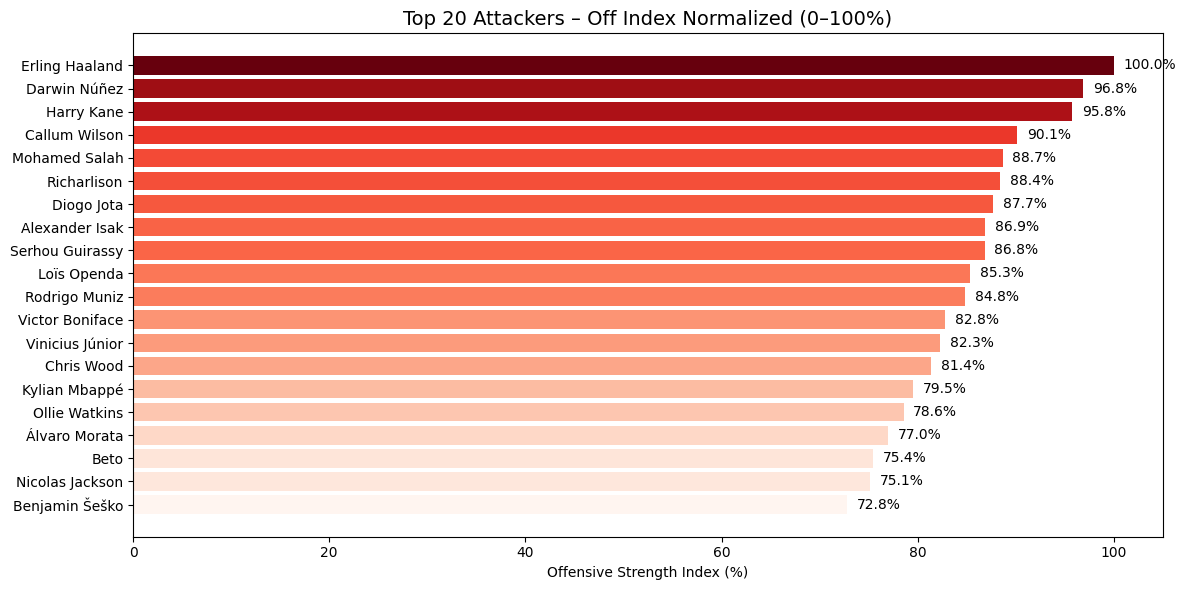

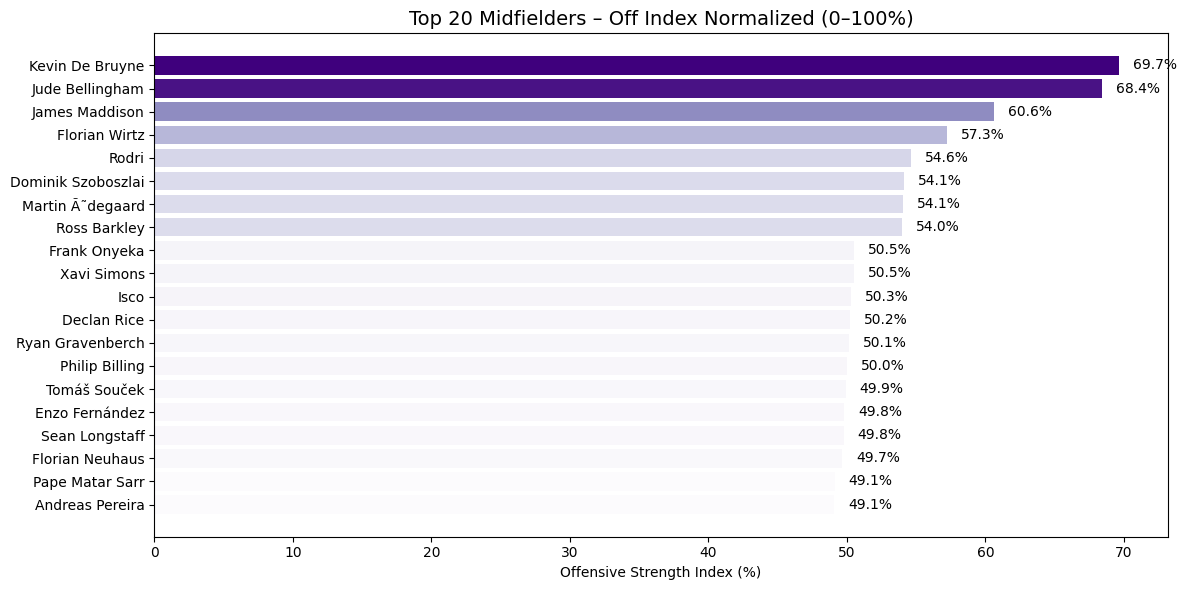

In [11]:
# Trouver 20 meilleurs attaquants et millieux par rapp à l'offensive Index

#df_last = (
   # df_clean.sort_values(["player", "season"])
      #.groupby("player")
      #.tail(1)             # prend la dernière saison pour chaque joueur
     # .reset_index(drop=True)
#)

df_last = df_clean[df_clean["season"] == 2023].copy()

#joueur avec min 10 matchs joués sur la saison
df_last2 = df_last[df_last["Minutes de jeu"] >= 900.0]

#Ajouter une ligne au data set df_last
coeff_dict = {
    "ENG-Premier League": 10.4303,
    "ITA-Serie A": 9.0284,
    "ESP-La Liga": 8.9489,
    "GER-Bundesliga": 8.6624,
    "FRA-Ligue 1": 6.6831,
}

# Ajouter la colonne coefficient dans ton df
df_last2["uefa_coefficient"] = df_last2["league"].map(coeff_dict)


# Vérifie
df_last2.head()


df_last2["OSI"] = (
    df_last2["G-PK"] * 3
    + (df_last2["G"] - df_last2["G-PK"]) * 0.5
    + df_last2["Tirs"] * 0.5
    + df_last2["Tirs cadrés"] * 1.8
    + df_last2["xG"] * 1.2
    + df_last2["xG / Tir"] * 0.5
    + df_last2["% duels aériens gagnés"] * 0.05                                                                                               #
    + df_last2["uefa_coefficient"]
)

df_last2["Off Index"] = (
    (df_last2["OSI"] - df_last2["OSI"].min())
    / (df_last2["OSI"].max() - df_last2["OSI"].min())
) * 100


df_sorted = df_last2.sort_values("Off Index", ascending=False)


# Séparer attaquants et milieux
df_attack = df_sorted[df_sorted["pos"] == "FW"].head(20)
df_mid = df_sorted[df_sorted["pos"] == "MF"].head(20)

def plot_top20(df_subset, title, cmap_name="Blues"):
    players = df_subset["player"]
    values = df_subset["Off Index"]

    # Normalisation pour couleurs
    norm = plt.Normalize(values.min(), values.max())
    colors = cm.get_cmap(cmap_name)(norm(values))

    plt.figure(figsize=(12, 6))
    bars = plt.barh(players, values, color=colors)

    # Inverser pour avoir le meilleur en haut
    plt.gca().invert_yaxis()

    # Ajouter le % affiché au bout de chaque barre
    for bar, val in zip(bars, values):
        plt.text(
            bar.get_width() + 1,
            bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%",
            va="center",
            ha="left",
            fontsize=10
        )

    plt.title(title, fontsize=14)
    plt.xlabel("Offensive Strength Index (%)")
    plt.tight_layout()
    plt.show()

# Plot attaquants
plot_top20(df_attack, "Top 20 Attackers – Off Index Normalized (0–100%)", cmap_name="Reds")

plot_top20(df_mid, "Top 20 Midfielders – Off Index Normalized (0–100%)", cmap_name="Purples")

/tmp/ipython-input-1030/1214847781.py:47: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap(cmap_name)(norm(values))


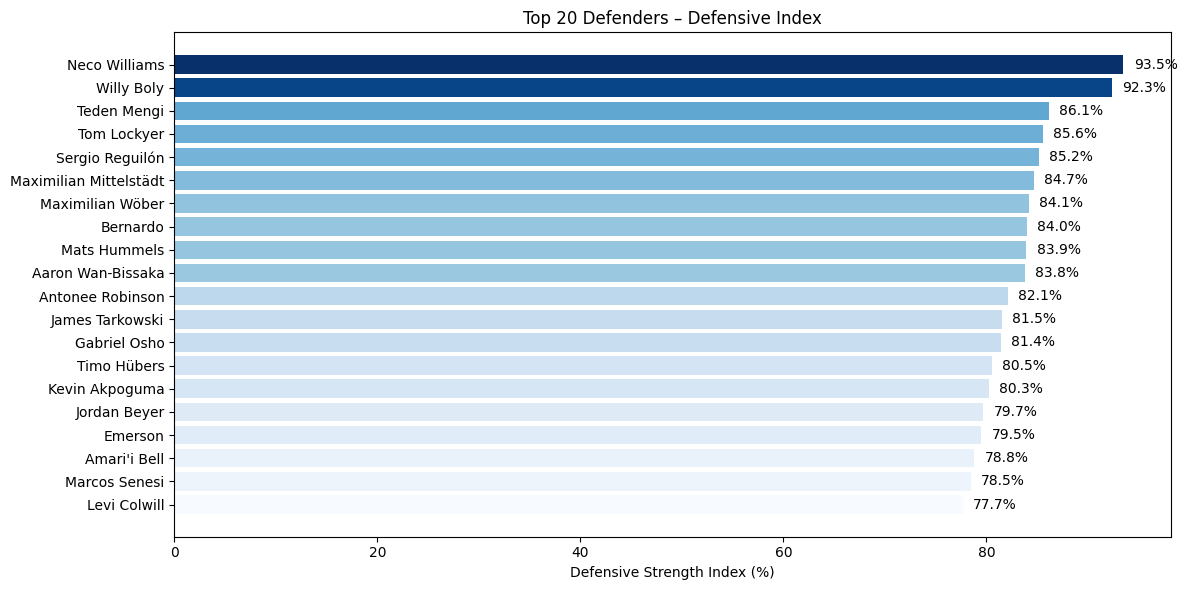

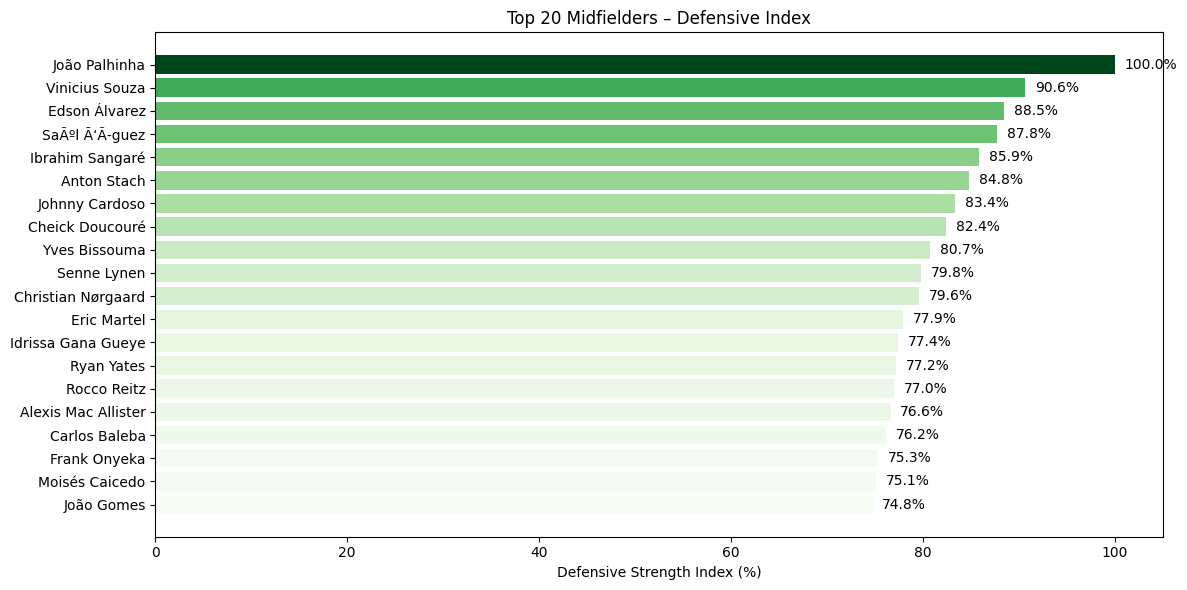

In [12]:
# Trouver 20 meilleurs défenseurs et millieux par rapp au déf Index
df_last2 = df_clean[df_clean["season"] == 2023].copy()

df_last2 = df_last2[df_last2["Minutes de jeu"] >= 900]


# Ajouter la colonne coefficient dans ton df
df_last2["uefa_coefficient_2023"] = df_last2["league"].map(coeff_dict)

#réduire le poids du % de passes réussies
df_last2["passes réussies ratio"] = df_last2["% passes réussies"] / 100

# Construire l’indice défensif
df_last2["DSI"] = (
    df_last2["Tacles réussis qui gagnent la balle"] * 2.0
    + df_last2["Interceptions"] * 2.5
    + df_last2["Blocs totaux"] * 2
    + df_last2["Dégagements"] * 0.5
    + df_last2["% duels aériens gagnés"] * 1
    + df_last2["passes réussies ratio"] * 0.8
    + df_last2["uefa_coefficient_2023"]
    - df_last2["Dribbles subis perdus"] * 1.2
    - df_last2["Erreurs menant à un tir adverse"] * 4
)

# Normalisation 0–100%
df_last2["Def Index"] = (
    (df_last2["DSI"] - df_last2["DSI"].min())
    / (df_last2["DSI"].max() - df_last2["DSI"].min())
) * 100

# Tri
df_sorted = df_last2.sort_values("Def Index", ascending=False)

# Sélection défenseurs (adapte selon tes labels : "DF" / "CB" / "LB" / "RB")
df_def = df_sorted[df_sorted["pos"] == "DF"].head(20)

# Sélection milieux
df_mid = df_sorted[df_sorted["pos"] == "MF"].head(20)

# ----- GRAPH FUNCTION -----
def plot_top20(df_subset, title, cmap_name="Greens"):
    players = df_subset["player"]
    values = df_subset["Def Index"]

    norm = plt.Normalize(values.min(), values.max())
    colors = cm.get_cmap(cmap_name)(norm(values))

    plt.figure(figsize=(12, 6))
    bars = plt.barh(players, values, color=colors)
    plt.gca().invert_yaxis()

    for bar, val in zip(bars, values):
        plt.text(
            bar.get_width() + 1,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%",
            va="center",
            ha="left",
            fontsize=10
        )

    plt.title(title)
    plt.xlabel("Defensive Strength Index (%)")
    plt.tight_layout()
    plt.show()

# Graphiques
plot_top20(df_def, "Top 20 Defenders – Defensive Index", cmap_name="Blues")
plot_top20(df_mid, "Top 20 Midfielders – Defensive Index", cmap_name="Greens")